# Fig 3

Fig 3. Regression analysis.


In [1]:
from pathlib import Path
import itertools
import math

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

font = FontProperties()
font.set_family("serif")
font.set_name("Times New Roman")
font.set_size(10)

plt.rcParams["figure.figsize"] = [3, 4]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
sns.set(style="white")
sns.set_context("paper", rc={"font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8})

config_load = "osm_home_15_place_15"
Y = "mixing_primary"
order = ["Boston", "Chicago", "Hong Kong", "London", "Sao Paulo"]
order_r = order[::-1]

structure = ["loghome_dist_center_poly", "loghome_dist_center_mono", "with_pub"]
PURPOSE = ["work", "education", "personal", "health", "recreation"]
purpose_prop = [f"{x}_prop" for x in PURPOSE]
behavior = ["privatet_per", "publict_per"]
income_cols = ["hhincomeq_4_2", "hhincomeq_4_3", "hhincomeq_4_4"]
age_cols = [
    "agegroup_12-17",
    "agegroup_18-24",
    "agegroup_25-34",
    "agegroup_35-44",
    "agegroup_45-54",
    "agegroup_55-64",
]
gender_cols = ["sex_f"]
work_cols = [
    "workstatus_employed",
    "workstatus_homemaker",
    "workstatus_illness",
    "workstatus_parttime",
    "workstatus_retired",
    "workstatus_student",
]
cat_vari = ["sex", "hhincomeq_4", "agegroup", "workstatus"]
colorder = ["who", "struc", "home", "behavior", "env", "density"]
colorder_r = ["env", "behavior", "struc", "home", "who", "density"]
FACTOR_COLOR = {
    "struc": "#3bc0cf",
    "env": "#0c7cba",
    "home": "#cfd1c2",
    "who": "#ef5c43",
    "behavior": "#b1d6f0",
    "density": "#ffdda6",
}


def resolve_data_path() -> Path:
    candidates = [
        Path.cwd() / "data" / "c_individual_all_osm_home_15_place_15.parquet",
        Path.cwd().parent / "data" / "c_individual_all_osm_home_15_place_15.parquet",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find data/c_individual_all_osm_home_15_place_15.parquet")


def sanitize(name: str) -> str:
    return name.lower().replace(".", "").replace(" ", "")


def pretty_token(token: str) -> str:
    replacements = {
        "art_museum": "Art & Museum",
        "poi_total": "POI Total",
        "privatet_per": "Private Transport",
        "publict_per": "Public Transport",
        "with_pub": "With Public Transport",
        "hh_mem": "HH Member",
        "with_car": "With Car",
        "is_parent": "Parent",
        "loghome_dist_center_poly": "Home Distance Poly",
        "loghome_dist_center_mono": "Home Distance Mono",
        "logmean_poi_total": "Destination POI Density",
        "hhincomeq_4_2": "Income 2",
        "hhincomeq_4_3": "Income 3",
        "hhincomeq_4_4": "Income 4",
        "sex_f": "Is Female",
    }
    if token in replacements:
        return replacements[token]
    if token.startswith("workstatus_"):
        return token.replace("workstatus_", "").replace("_", " ").title()
    if token.startswith("agegroup_"):
        return token.replace("agegroup_", "Age ")
    if token.startswith("loghome_"):
        return "Home " + token.replace("loghome_", "").replace("_", " ").title()
    if token.startswith("mean_") and token.endswith("_prop"):
        return token.replace("mean_", "").replace("_prop", "").replace("_", " ").title()
    return token.replace("_", " ").title()


DATA_PATH = resolve_data_path()
DATA_PATH


PosixPath('/Users/yuan/Dropbox (Personal)/Personal Work/_Projects_GIT/social-mixing-5-city/data/c_individual_all_osm_home_15_place_15.parquet')

In [2]:
def load_data(data_path: Path):
    df = pd.read_parquet(data_path)

    raw_dest_poi = [x for x in df.columns if x.startswith("mean_") and x != "mean_poi_total"]
    raw_home_env = [
        x
        for x in df.columns
        if x.startswith("home_")
        and x not in {"home_h3_8", "home_dist_center_mono", "home_dist_center_poly"}
    ]

    df.columns = [sanitize(x) for x in df.columns]
    dest_poi = [sanitize(x) for x in raw_dest_poi]
    dest_poi_prop = [f"{x}_prop" for x in dest_poi]
    home_env = [sanitize(x) for x in raw_home_env]
    log_home_env = [f"log{x}" for x in home_env]

    full_labels = {
        sanitize(x): pretty_token(sanitize(x)) for x in raw_dest_poi + raw_home_env
    }
    full_labels.update({x: pretty_token(x) for x in structure + behavior + income_cols + age_cols + gender_cols + work_cols})
    full_labels.update({x: pretty_token(x) for x in dest_poi_prop})
    full_labels["logmean_poi_total"] = pretty_token("logmean_poi_total")
    for x in log_home_env:
        full_labels[x] = pretty_token(x)

    df = df[df["age"] > 11].reset_index(drop=True)
    df = df[df["leg_count"] > 0].reset_index(drop=True)
    df = df[df["sex"].notnull()].reset_index(drop=True)
    for cat in cat_vari:
        if cat in df.columns:
            df = pd.concat([df, pd.get_dummies(df[cat], prefix=cat)], axis=1)
    df = df.drop([c for c in cat_vari if c in df.columns], axis=1)
    df.columns = [sanitize(c) for c in df.columns]

    df["is_parent"] = df["is_mum"].astype(bool) | df["is_dad"].astype(bool)
    df["with_pub"] = (df["with_bus"] > 0) | (df["with_train"] > 0)
    df = df[df["total_dist"] > 0].reset_index(drop=True)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df[~df[Y].isna()].reset_index(drop=True)

    for dest in dest_poi:
        df[dest] = df[dest].fillna(0)
    dest_totals = df[dest_poi].sum(axis=1) + 1
    for dest in dest_poi:
        df[f"{dest}_prop"] = df[dest] / dest_totals
    df["mean_poi_total"] = dest_totals

    for home_col in home_env:
        df[home_col] = df[home_col].fillna(0)

    for col in ["home_dist_center_mono", "home_dist_center_poly", "leg_count", "total_dist", "mean_poi_total"]:
        df[f"log{col}"] = np.log(df[col] + 1)

    for pur in PURPOSE:
        pur_clean = sanitize(pur)
        if pur_clean in df.columns:
            df[pur_clean] = df[pur_clean].fillna(0)
            df[f"{pur_clean}_prop"] = df[pur_clean] / df["leg_count"]

    who_candidates = ["is_parent", "hh_mem", "with_car"] + income_cols + age_cols + gender_cols + work_cols
    variables = {
        "behavior": [x for x in behavior if x in df.columns],
        "env": [x for x in dest_poi_prop if x in df.columns],
        "density": [x for x in ["logmean_poi_total"] if x in df.columns],
        "home": [x for x in log_home_env if x in df.columns],
        "struc": [x for x in structure if x in df.columns],
        "who": [x for x in who_candidates if x in df.columns],
    }
    variables = {key: value for key, value in variables.items() if value}
    return df, full_labels, variables


def get_unique_combinations(variables):
    orders = list(itertools.permutations(variables.keys()))
    all_combinations = []
    for order_group in orders:
        for i in range(len(order_group)):
            all_combinations.append(sorted(order_group[: i + 1]))
    unique_combinations = []
    for combo in all_combinations:
        if combo not in unique_combinations:
            unique_combinations.append(combo)
    return unique_combinations


def get_r2_groups(df, city, variables):
    df_city = df[df["city_short"] == city].reset_index(drop=True)
    if df_city.empty:
        return []
    combinations = get_unique_combinations(variables)
    r2_groups = []
    for combo in combinations:
        variable_temp = [item for key in combo for item in variables[key]]
        if not variable_temp:
            continue
        X = df_city[variable_temp]
        y = df_city[Y]
        model_df = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)
        if model_df.empty:
            continue
        X_fit = model_df[variable_temp]
        y_fit = model_df[Y]
        model = LinearRegression().fit(X_fit, y_fit)
        r2 = r2_score(y_fit, model.predict(X_fit))
        r2_groups.append({"order": "_".join(combo), "r2": r2, "sample_size": df_city.shape[0]})
    return r2_groups


def get_r2wide(df, variables):
    resultdf = []
    for city in df["city_short"].unique():
        scores = get_r2_groups(df, city, variables)
        if scores:
            score_df = pd.DataFrame(scores)
            score_df["city_short"] = city
            resultdf.append(score_df)
    resultdf = pd.concat(resultdf).reset_index(drop=True)
    return resultdf.pivot(columns="order", values="r2", index="city_short").reset_index()


def get_lmg(r2wide, city, variables, tol=1e-12):
    r2_values = r2wide.loc[r2wide["city_short"] == city].to_dict("records")[0]
    factors = sorted(variables.keys())
    lmg_totals = {f: 0.0 for f in factors}
    for ordering in itertools.permutations(factors):
        prev = 0.0
        for i, factor in enumerate(ordering):
            subset = tuple(sorted(ordering[: i + 1]))
            curr = r2_values["_".join(subset)]
            delta = max(curr - prev, 0.0)
            if delta < -tol:
                delta = 0.0
            lmg_totals[factor] += delta
            prev = curr
    nperm = math.factorial(len(factors))
    avg_contrib = {f: lmg_totals[f] / nperm for f in factors}
    total = sum(avg_contrib.values())
    lmg_pct = {f: (avg_contrib[f] / total) * 100.0 for f in factors}
    result = pd.DataFrame([lmg_pct], index=[city])
    result.index.name = "city"
    return result


def get_lmg_all(df, variables):
    r2wide = get_r2wide(df, variables)
    lmg_df = pd.concat([get_lmg(r2wide, city, variables) for city in r2wide["city_short"].unique()]).reset_index()
    return lmg_df, r2wide


def get_full_coefficient(df, city, variables):
    df_city = df[df["city_short"] == city].reset_index(drop=True)
    variable_cols = [item for sublist in variables.values() for item in sublist]
    model_df = df_city[variable_cols + [Y]].dropna().reset_index(drop=True)
    if model_df.empty:
        return []
    X = model_df[variable_cols].copy()
    X = X.loc[:, X.nunique(dropna=False) > 1]
    if X.empty:
        return []
    X_scaled = StandardScaler().fit_transform(X)
    y = StandardScaler().fit_transform(model_df[Y].values.reshape(-1, 1)).flatten()
    model = sm.OLS(y, sm.add_constant(X_scaled)).fit()
    coefficients = model.params[1:]
    p_values = model.pvalues[1:]
    return [[col, coef, p] for col, coef, p in zip(X.columns, coefficients, p_values)]


df, full_labels, variables = load_data(DATA_PATH)
df[["city_short", Y]].head()


,city_short,mixing_primary
0,Chicago,0.887485
1,Chicago,0.898731
2,Chicago,0.873669
3,Chicago,0.452319
4,Chicago,0.530919


## Coefficients


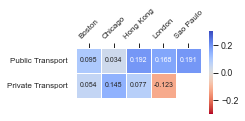

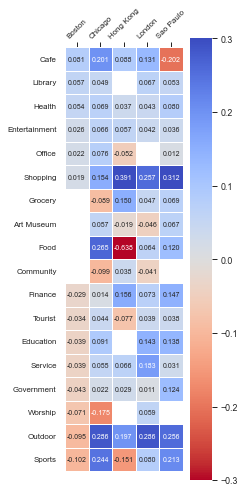

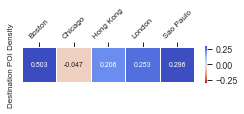

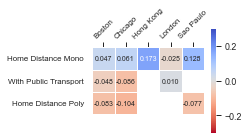

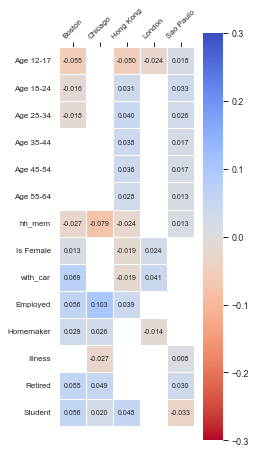

['behavior', 'env', 'density', 'struc', 'who']

In [3]:
def get_coef_all(df):
    coef_all = []
    for city in df["city_short"].unique():
        coef_df = pd.DataFrame(get_full_coefficient(df, city, variables), columns=["variable", "coef", "p"])
        coef_df["city"] = city
        coef_all.append(coef_df)
    coef_all = pd.concat(coef_all).reset_index(drop=True)
    coef_all_filter = coef_all[coef_all["p"] < 0.05].reset_index(drop=True)
    coef_all_filter["variable_type"] = coef_all_filter["variable"].apply(
        lambda x: next(key for key in variables.keys() if x in variables[key])
    )
    return coef_all_filter


def viz_one_variable(coef_all_filter, sel, sort=True):
    coef_sel = coef_all_filter[coef_all_filter["variable_type"] == sel].reset_index(drop=True)
    if coef_sel.empty:
        return None
    data_viz = coef_sel.pivot(index="variable", columns="city", values="coef").fillna(0)
    if sort and "Boston" in data_viz.columns:
        data_viz = data_viz.sort_values(by="Boston", ascending=False)
    n_rows = data_viz.shape[0]
    fig, ax = plt.subplots(figsize=(3.5, 0.4 * n_rows + 1))
    mask = data_viz == 0
    sns.heatmap(
        data=data_viz,
        cmap="coolwarm_r",
        center=0,
        fmt=".3f",
        vmin=-0.3,
        vmax=0.3,
        square=True,
        linewidths=0.5,
        linecolor="white",
        mask=mask,
        annot=True,
        annot_kws={"size": 7},
        ax=ax,
    )
    y_tick_labels = [full_labels.get(item, item) for item in data_viz.index]
    ax.set_yticks(np.arange(len(y_tick_labels)) + 0.5)
    ax.set_yticklabels(y_tick_labels, fontsize=8)
    ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
    ax.set_xticks(np.arange(len(data_viz.columns)) + 0.5)
    ax.set_xticklabels(list(data_viz.columns), fontsize=8, rotation=45)
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    return fig, ax


coef_all_filter = get_coef_all(df)
coef_figures = {}
for key in variables.keys():
    coef_result = viz_one_variable(coef_all_filter, key, sort=(key != "who"))
    if coef_result is not None:
        coef_figures[key] = coef_result
        plt.show()

list(coef_figures.keys())


## LMG Analysis


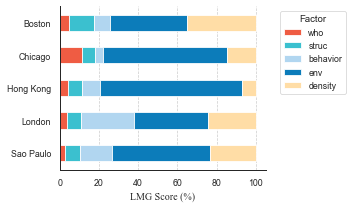

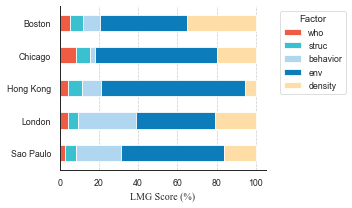

city_short,order,Boston,Chicago,Hong Kong,London,Sao Paulo,variable_group
0,behavior,0.109,0.019,0.037,0.123,0.093,M
1,behavior_density,0.368,0.134,0.068,0.181,0.211,M+D
2,behavior_density_env,0.429,0.321,0.264,0.232,0.313,M+D+PD
3,behavior_density_env_struc,0.431,0.326,0.289,0.232,0.320,M+D+PD+H
4,behavior_density_env_struc_who,0.439,0.340,0.296,0.236,0.322,M+D+PD+H+S


In [4]:
variable_group_dict = {
    "behavior": "M",
    "env": "PD",
    "home": "PH",
    "struc": "H",
    "who": "S",
    "density": "D",
}


def plot_lmg_order(lmg_df, order, title_suffix="full"):
    fig, ax = plt.subplots(figsize=(5, 3))
    colorder_update = [factor for factor in colorder if factor in lmg_df.columns]
    data = lmg_df.set_index("city").reindex(order)[colorder_update]
    data.plot(
        kind="barh",
        stacked=True,
        color=[FACTOR_COLOR[factor] for factor in colorder_update],
        edgecolor="white",
        ax=ax,
    )
    ax.set_xlabel("LMG Score (%)", fontproperties=font)
    ax.set_ylabel("")
    ax.grid(True, which="major", axis="x", linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="Factor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    return fig, ax


lmg_df, r2wide = get_lmg_all(df, variables)
lmg_df_s, r2wide_s = get_lmg_all(df[df["home_dist_center_mono"] < 30000], variables)
r2long = r2wide.set_index("city_short").T.reset_index()
r2long["variable_group"] = r2long["order"].apply(lambda x: "+".join([variable_group_dict[y] for y in x.split("_")]))
for col in r2long.columns[1:-1]:
    r2long[col] = r2long[col].round(3)

fig_lmg_full, ax_lmg_full = plot_lmg_order(lmg_df, order_r, title_suffix="wm_10min")
plt.show()
fig_lmg_small, ax_lmg_small = plot_lmg_order(lmg_df_s, order_r, title_suffix="wm_10min_30k")
plt.show()
r2long.head()


## Ring Analysis


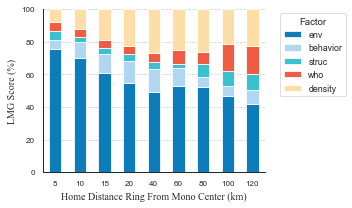

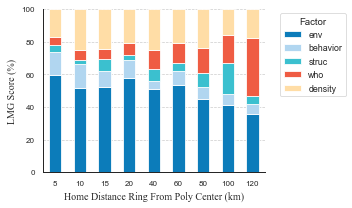

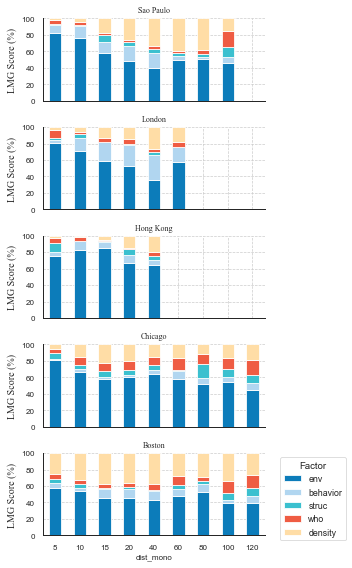

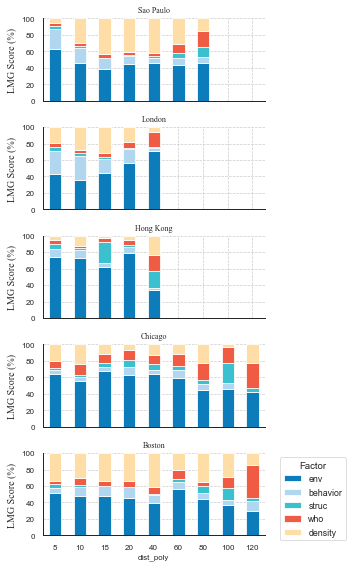

: 

In [ ]:
def get_ring_results(df_source, center_type="mono"):
    lmg_summary_rings = []
    dist_range = [5, 10, 15, 20, 40, 60, 80, 100, 120]
    for i, dist in enumerate(dist_range):
        if i == 0:
            subset = df_source[df_source[f"home_dist_center_{center_type}"] < dist * 1000]
        else:
            subset = df_source[
                (df_source[f"home_dist_center_{center_type}"] < dist * 1000)
                & (df_source[f"home_dist_center_{center_type}"] >= dist_range[i - 1] * 1000)
            ]
        lmg_temp, _ = get_lmg_all(subset, variables)
        lmg_temp[f"dist_{center_type}"] = dist
        lmg_summary_rings.append(lmg_temp)
    lmg_summary_rings = pd.concat(lmg_summary_rings).reset_index(drop=True)
    lmg_summary_rings_mean = (
        lmg_summary_rings.drop("city", axis=1).groupby(f"dist_{center_type}").mean().reset_index()
    )
    return lmg_summary_rings_mean, lmg_summary_rings


def plot_ring(lmg_summary_rings_mean, center_type="mono"):
    width = int(lmg_summary_rings_mean.shape[0] ** 0.5) + 2
    fig, ax = plt.subplots(figsize=(width, 3))
    colorder_update = [factor for factor in colorder_r if factor in lmg_summary_rings_mean.columns]
    data = lmg_summary_rings_mean.set_index(f"dist_{center_type}")[colorder_update]
    data.plot(kind="bar", stacked=True, color=[FACTOR_COLOR[factor] for factor in colorder_update], ax=ax)
    ax.set_ylim(0, 100)
    ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.7)
    ax.set_xlabel(f"Home Distance Ring From {center_type.title()} Center (km)", fontproperties=font)
    ax.set_ylabel("LMG Score (%)", fontproperties=font)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", labelsize=8)
    ax.xaxis.set_tick_params(rotation=0)
    ax.legend(title="Factor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    return fig, ax


def plot_ring_city(lmg_summary_rings, center_type="mono"):
    colorder_update = [factor for factor in colorder_r if factor in lmg_summary_rings.columns]
    fig, axes = plt.subplots(5, 1, figsize=(5, 8), sharey=True, sharex=True)
    for city, ax in zip(order_r, axes.flatten()):
        data = (
            lmg_summary_rings[lmg_summary_rings["city"] == city]
            .reset_index(drop=True)
            .set_index(f"dist_{center_type}")[colorder_update]
        )
        data.plot(kind="bar", stacked=True, color=[FACTOR_COLOR[factor] for factor in colorder_update], ax=ax)
        ax.set_ylim(0, 100)
        ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.7)
        ax.set_ylabel("LMG Score (%)", fontproperties=font)
        ax.set_title(city, fontproperties=font, fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", which="major", labelsize=8)
        ax.xaxis.set_tick_params(rotation=0)
        if ax.legend_ is not None:
            ax.legend_.remove()
    plt.legend(title="Factor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    return fig, axes


lmg_summary_rings_mean, lmg_summary_rings = get_ring_results(df, center_type="mono")
lmg_summary_rings_mean_p, lmg_summary_rings_p = get_ring_results(df, center_type="poly")

fig_ring_mono, ax_ring_mono = plot_ring(lmg_summary_rings_mean, center_type="mono")
plt.show()
fig_ring_poly, ax_ring_poly = plot_ring(lmg_summary_rings_mean_p, center_type="poly")
plt.show()
fig_ring_city_mono, axes_ring_city_mono = plot_ring_city(lmg_summary_rings, center_type="mono")
plt.show()
fig_ring_city_poly, axes_ring_city_poly = plot_ring_city(lmg_summary_rings_p, center_type="poly")
plt.show()
